# Stage 1: Exploratory Data Analysis (EDA) - Spotify Tracks Dataset
**Objective:** Audit data integrity, evaluate statistical distributions, analyze linear correlations, and extract strategic business insights across artist performance, genre streaming demand, and acoustic features.

In [36]:
# 1. Imports and Global Plotting Configuration
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Visual Configurations
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
pd.set_option('display.max_columns', None)

## 1. Data Ingestion & Structural Audit
Load processed dataset and inspect structural dimensions, data types, and initial memory footprint.

In [37]:
# 2. Data Ingestion
df = pd.read_csv('../data/spotify_data_processed.csv')
df.head()

,track_id,track_name,artist_name,album_name,release_date,genre,duration_ms,popularity,danceability,energy,key,loudness,mode,instrumentalness,tempo,stream_count,country,explicit,label,release_year,release_month,release_day_of_week,duration_minutes,popularity_category,loudness_category,key_name,mode_name,is_explicit_bool,release_quarter,is_weekend_release,log_stream_count,upbeat_score,artist_track_count
0,TRK-BEBD53DA84E1,Agent every (0),Noah Rhodes,Beautiful instead,2016-04-01,Pop,234194,55,0.15,0.74,9,-32.22,0,0.44,73.12,13000,Brazil,0,Universal Music,2016,4,Friday,3.90,Medium,Quiet,A,Minor,False,2,False,9.47,0.45,1
1,TRK-6A32496762D7,Night respond,Jennifer Cole,Table,2022-04-15,Metal,375706,45,0.44,0.46,0,-14.02,0,0.22,157.74,1000,France,1,Island Records,2022,4,Friday,6.26,Medium,Moderate,C,Minor,True,2,False,6.91,0.45,3
2,TRK-47AA7523463E,Future choice whatever,Brandon Davis,Page southern,2016-02-23,Rock,289191,55,0.62,0.80,8,-48.26,1,0.58,71.03,1000,Germany,1,XL Recordings,2016,2,Tuesday,4.82,Medium,Quiet,G#,Major,True,1,False,6.91,0.71,2
3,TRK-25ADA22E3B06,Bad fall pick those,Corey Jones,Spring,2015-10-12,Pop,209484,51,0.78,0.98,1,-34.47,1,0.68,149.00,1000,France,0,Warner Music,2015,10,Monday,3.49,Medium,Quiet,C#,Major,False,4,False,6.91,0.88,4
4,TRK-9245F2AD996A,Husband,Mark Diaz,Great prove,2022-07-08,Indie,127435,39,0.74,0.18,10,-17.84,0,0.30,155.85,2000,United States,0,Independent,2022,7,Friday,2.12,Medium,Moderate,A#,Minor,False,3,False,7.60,0.46,2


In [38]:
# Check dataset shape (rowa, columns)
print(f"Total Records (Row): {df.shape[0]:,}")
print(f"Total Features (Columns): {df.shape[1]}")

# Display data types and memory footprint
df.info()

Total Records (Row): 85,000
Total Features (Columns): 33
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 85000 entries, 0 to 84999
Data columns (total 33 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   track_id             85000 non-null  object 
 1   track_name           85000 non-null  object 
 2   artist_name          85000 non-null  object 
 3   album_name           85000 non-null  object 
 4   release_date         85000 non-null  object 
 5   genre                85000 non-null  object 
 6   duration_ms          85000 non-null  int64  
 7   popularity           85000 non-null  int64  
 8   danceability         85000 non-null  float64
 9   energy               85000 non-null  float64
 10  key                  85000 non-null  int64  
 11  loudness             85000 non-null  float64
 12  mode                 85000 non-null  int64  
 13  instrumentalness     85000 non-null  float64
 14  tempo                85000 no

## 2. Data Quality & Statistical Summary
Audit dataset for missing records, duplicate entries, and review five-number summary metrics.

In [39]:
# Identify missing values per column
missing_values = df.isnull().sum()
missing_columns = missing_values[missing_values > 0]

print("Columns with missing values:")
print(missing_columns if not missing_columns.empty else "No missing values found.")

# Identify and remove duplicate rows
duplicates_count = df.duplicated().sum()
print(f"\nTotal duplicate rows found: {duplicates_count}")

if duplicates_count > 0:
    df = df.drop_duplicates()
    print("Duplicates successfully removed.")

Columns with missing values:
No missing values found.

Total duplicate rows found: 0


In [40]:
# Format table with thousands separators and 2 decimal places
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')
df.describe().T

,count,mean,std,min,25%,50%,75%,max
duration_ms,"85,000.00","254,913.82","95,300.23","90,004.00","171,871.50","254,920.50","337,203.25","420,000.00"
popularity,"85,000.00",48.16,14.83,0.00,38.00,47.00,57.00,100.00
danceability,"85,000.00",0.52,0.27,0.05,0.29,0.52,0.76,0.99
energy,"85,000.00",0.51,0.28,0.02,0.26,0.50,0.75,0.99
key,"85,000.00",5.52,3.45,0.00,2.75,6.00,9.00,11.00
loudness,"85,000.00",-28.00,15.60,-55.00,-41.47,-27.97,-14.50,-1.00
mode,"85,000.00",0.50,0.50,0.00,0.00,1.00,1.00,1.00
instrumentalness,"85,000.00",0.40,0.23,0.00,0.20,0.40,0.60,0.80
tempo,"85,000.00",129.95,40.44,60.00,94.84,129.99,165.03,200.00
stream_count,"85,000.00","214,354.68","1,680,637.47","1,000.00","1,000.00","2,000.00","9,000.00","20,000,000.00"


## 3. Target Distribution & Correlation Analysis
Analyze the normality of track popularity scores and inspect collinearity between acoustic metrics.

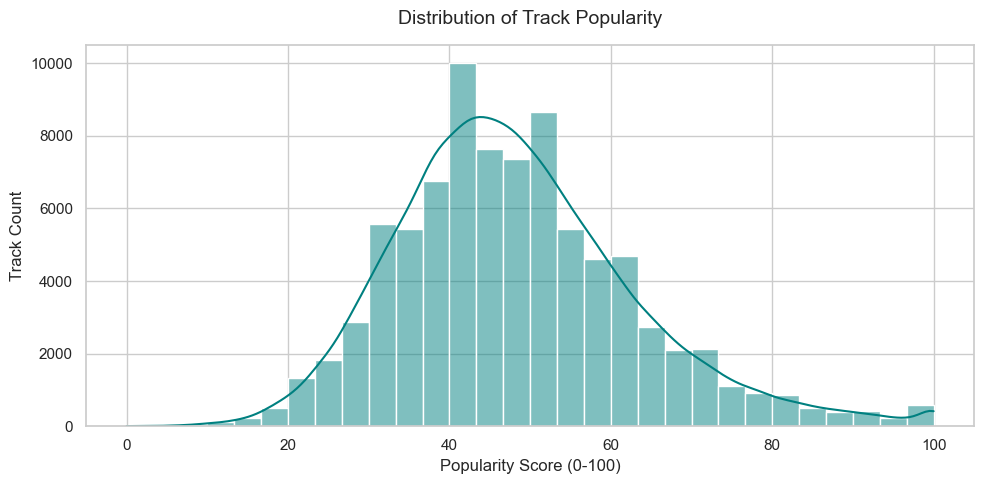

In [41]:
# Distribution of Track Popularity
plt.figure(figsize=(10, 5))
sns.histplot(df['popularity'], bins=30, kde=True, color='teal')
plt.title('Distribution of Track Popularity', fontsize=14, pad=15)
plt.xlabel('Popularity Score (0-100)')
plt.ylabel('Track Count')
plt.tight_layout()
plt.show()

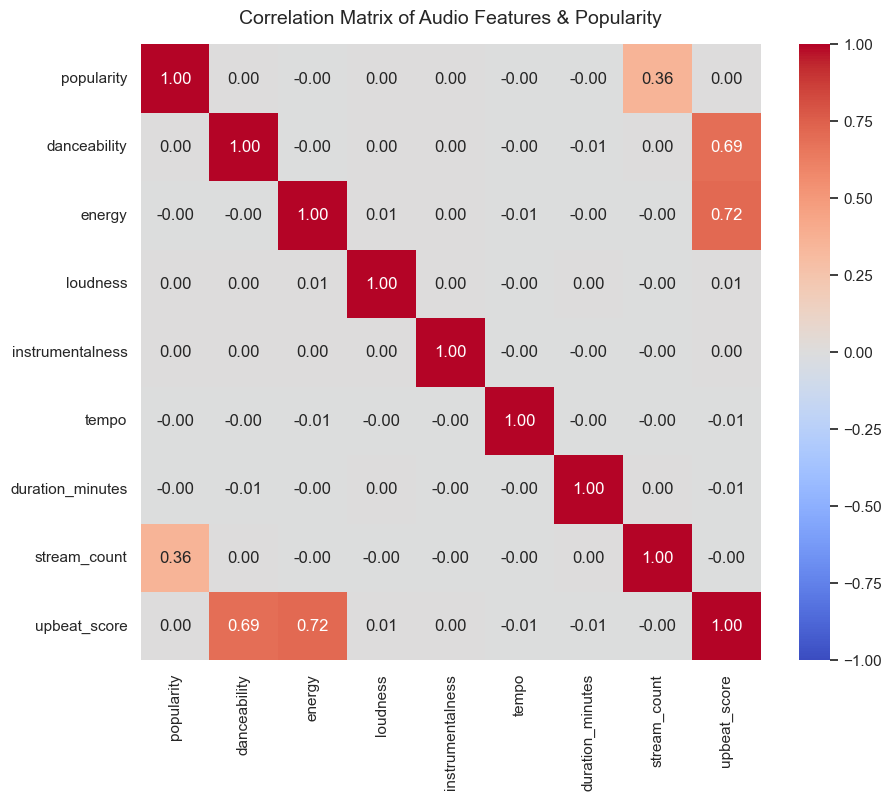

In [42]:
# Select key numerical audio features for correlation
audio_features = [
    'popularity', 'danceability', 'energy',
    'loudness', 'instrumentalness', 'tempo', 
    'duration_minutes', 'stream_count', 'upbeat_score'
]

# Calculate correlation matrix
correlation_matrix = df[audio_features].corr()

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Matrix of Audio Features & Popularity', fontsize=14, pad=15)
plt.show()

## 4. Business Questions & Strategic Analytics

### 4.1 Which artists generate the highest streaming performance and efficiency?

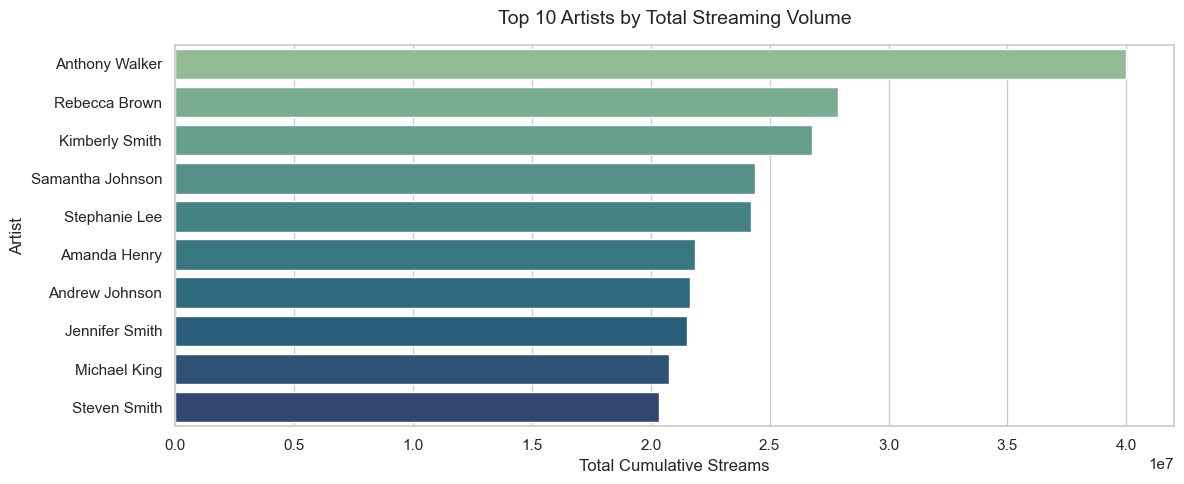

In [43]:
# Filter artists with at least 5 tracks to prevent single-track skew
artist_perf = df.groupby('artist_name').agg(
    total_streams=('stream_count', 'sum'),
    track_count=('track_id', 'count'),
    avg_popularity=('popularity', 'mean')
).query('track_count >= 5')

artist_perf['streams_per_track'] = artist_perf['total_streams'] / artist_perf['track_count']
top_stream_artists = artist_perf.sort_values(by='total_streams', ascending=False).head(10)

plt.figure(figsize=(12, 5))
sns.barplot(
    data=top_stream_artists.reset_index(),
    x='total_streams',
    y='artist_name',
    palette='crest'
)
plt.title('Top 10 Artists by Total Streaming Volume', fontsize=14, pad=15)
plt.xlabel('Total Cumulative Streams')
plt.ylabel('Artist')
plt.tight_layout()
plt.show()

### 4.2 Which music genres generate the most total streams?

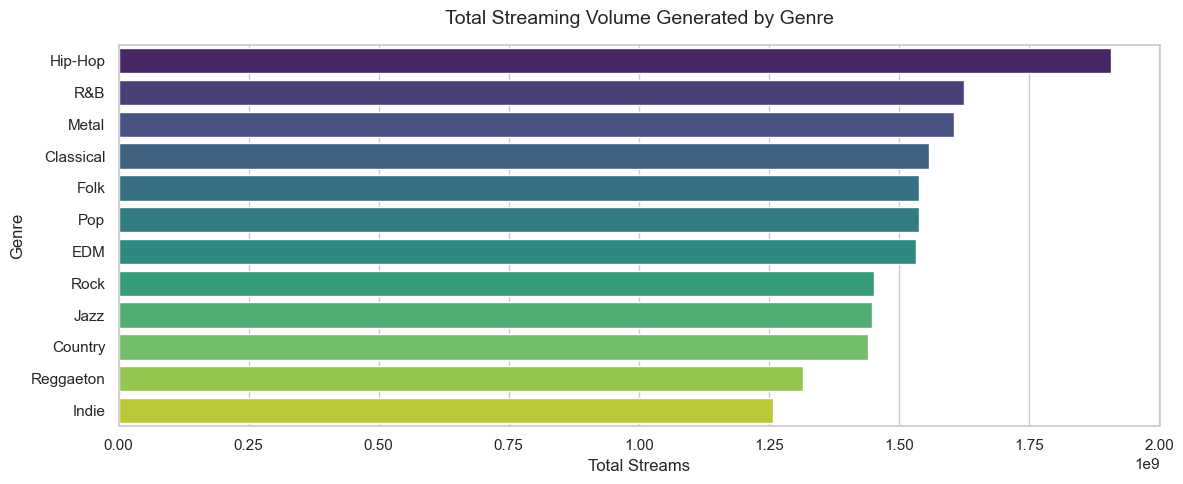

In [44]:
genre_streams = (
    df.groupby('genre')['stream_count']
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

plt.figure(figsize=(12, 5))
sns.barplot(
    data=genre_streams,
    x='stream_count',
    y='genre',
    palette='viridis'
)
plt.title('Total Streaming Volume Generated by Genre', fontsize=14, pad=15)
plt.xlabel('Total Streams')
plt.ylabel('Genre')
plt.tight_layout()
plt.show()

### 4.3 What is the impact of explicit content on popularity and streams?

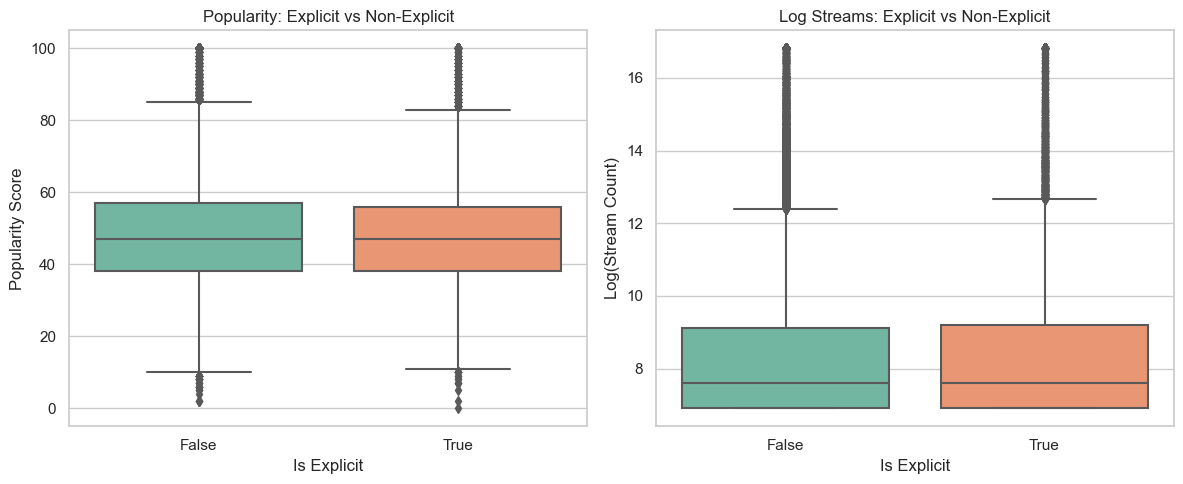

In [45]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.boxplot(data=df, x='is_explicit_bool', y='popularity', palette='Set2')
plt.title('Popularity: Explicit vs Non-Explicit', fontsize=12)
plt.xlabel('Is Explicit')
plt.ylabel('Popularity Score')

plt.subplot(1, 2, 2)
sns.boxplot(data=df, x='is_explicit_bool', y='log_stream_count', palette='Set2')
plt.title('Log Streams: Explicit vs Non-Explicit', fontsize=12)
plt.xlabel('Is Explicit')
plt.ylabel('Log(Stream Count)')

plt.tight_layout()
plt.show()

## 5. Temporal Dynamics & Feature Profiling

### 5.1 How has music streaming volume and popularity evolved from 2015 to 2025?

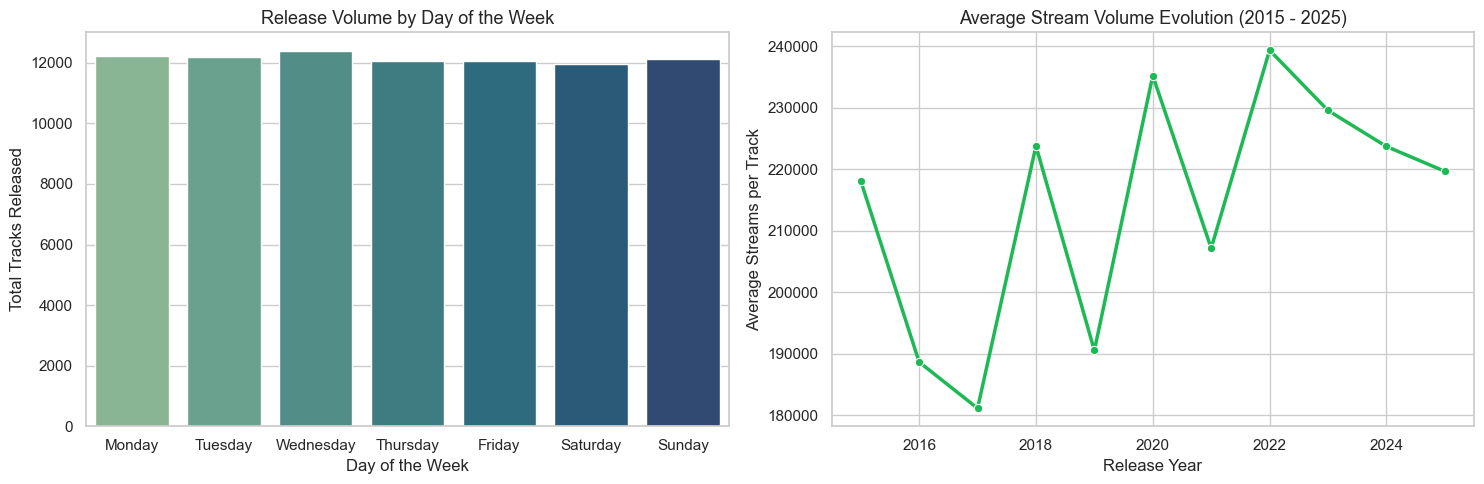

In [46]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Day of week release volume
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
sns.countplot(data=df, x='release_day_of_week', order=day_order, palette='crest', ax=axes[0])
axes[0].set_title('Release Volume by Day of the Week', fontsize=13)
axes[0].set_xlabel('Day of the Week')
axes[0].set_ylabel('Total Tracks Released')

# Multi-year streaming trend
yearly_trend = df.groupby('release_year')['stream_count'].mean().reset_index()
sns.lineplot(data=yearly_trend, x='release_year', y='stream_count', marker='o', color='#1DB954', lw=2.5, ax=axes[1])
axes[1].set_title('Average Stream Volume Evolution (2015 - 2025)', fontsize=13)
axes[1].set_xlabel('Release Year')
axes[1].set_ylabel('Average Streams per Track')

plt.tight_layout()
plt.show()

### 5.2 What acoustic characteristics distinguish popular hits from standard catalog tracks?

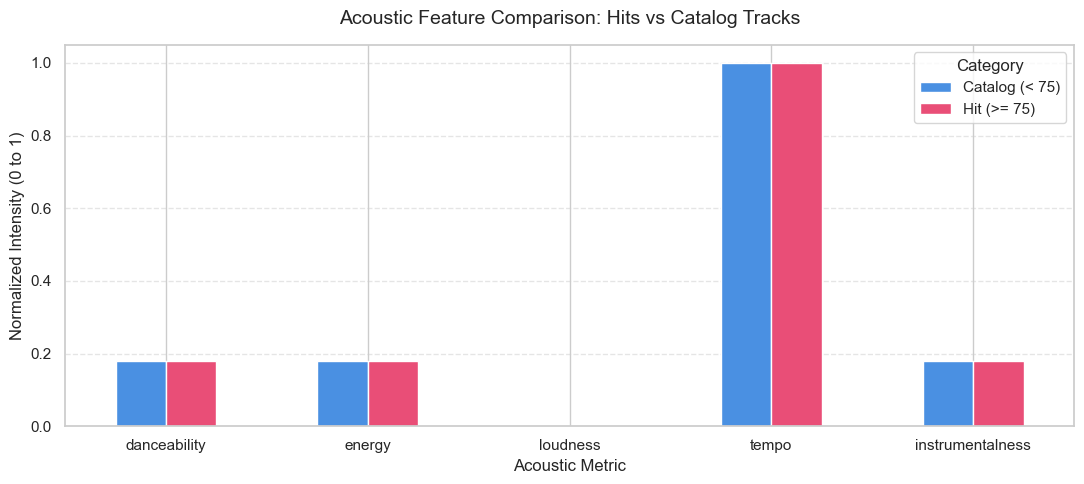

Top 10 Record Labels Performance Summary:
          label  total_tracks  avg_popularity  total_streams
    Independent         10767           48.26     2383670000
       Columbia         10690           48.09     2162425000
  XL Recordings         10687           48.21     2103665000
     Sony Music         10631           48.33     2420776000
   Warner Music         10619           47.90     2242209000
            EMI         10574           48.30     2451411000
 Island Records         10527           48.00     2179514000
Universal Music         10505           48.20     2276478000


In [47]:
# Segment breakout hits from standard catalog
df['is_hit'] = np.where(df['popularity'] >= 75, 'Hit (>= 75)', 'Catalog (< 75)')

acoustic_cols = ['danceability', 'energy', 'loudness', 'tempo', 'instrumentalness']
hit_comparison = df.groupby('is_hit')[acoustic_cols].mean().T

# Min-max normalization across features to allow direct scale comparison
hit_comparison_norm = (hit_comparison - hit_comparison.min()) / (hit_comparison.max() - hit_comparison.min())

hit_comparison_norm.plot(
    kind='bar',
    figsize=(11, 5),
    color=['#4A90E2', '#E94E77'],
    rot=0
)
plt.title('Acoustic Feature Comparison: Hits vs Catalog Tracks', fontsize=14, pad=15)
plt.xlabel('Acoustic Metric')
plt.ylabel('Normalized Intensity (0 to 1)')
plt.legend(title='Category')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# Top 10 record labels performance overview
top_labels = (
    df.groupby('label')
    .agg(
        total_tracks=('track_id', 'count'),
        avg_popularity=('popularity', 'mean'),
        total_streams=('stream_count', 'sum')
    )
    .sort_values(by='total_tracks', ascending=False)
    .head(10)
    .reset_index()
)

print("Top 10 Record Labels Performance Summary:")
print(top_labels.to_string(index=False))

## 6. Key Exploratory Findings & Business Takeaways

* **Target Distribution:** Popularity follows a near-normal distribution centered around ~48.2 points, with high-popularity breakout hits ($\ge 75$) representing a distinct minority of the catalog.
* **Linear Feature Independence:** Standalone acoustic features (danceability, energy, tempo, loudness) exhibit near-zero linear correlation with popularity scores, proving that simple linear models cannot capture hit potential.
* **Streaming Asymmetry:** Stream volume shows a moderate positive correlation (0.36) with popularity, exhibiting high right-skewness where top performers concentrate disproportionate streaming volume.
* **Genre & Label Performance:** While average popularity is uniformly distributed across genres and major labels, overall market streaming demand is concentrated in specific commercial categories.
* **Next Step (Stage 2 & 3):** Relational SQL schema design (Stage 2) followed by non-linear machine learning modeling with ensemble tree algorithms (Stage 3) to model multi-feature non-linear interactions.